# Assignment 02 - Application 3: E-Commerce Customer Behaviour & Interest

**Student:** _<your name>_ &nbsp;&nbsp; **ID:** _<your id>_ &nbsp;&nbsp; **Class:** _<class>_
&nbsp;&nbsp; **Date:** 2026-09-06

Built from the raw Sephora skincare review tables through to a persisted model that the
web and mobile services load unchanged. Twenty-three sections + two appendices, following

```
Data -> Understand -> Clean -> Represent -> Learn -> Evaluate -> Persist -> Deploy
```

**Task.** For one product review, predict whether the customer **recommends the product**
(`is_recommended`), from **(a)** the customer's skin profile + the product + review timing
(*tabular*) and **(b)** the review text. The assignment's core question is the
**representation comparison**: how far does structured data alone get, how far does the
text alone get, and does combining them help?

**Headline result.** Tabular alone -> ROC-AUC ~0.77 (linear) / ~0.81 (trees). Review text
alone -> ~0.965. Both -> ~0.964, macro-F1 ~0.86, recall on the minority "not recommend"
class ~0.88 (**deployed**). Section 14a shows both representations carry real skill, the
text leads (partly because it is **co-authored with the recommend flag**), and combining
adds a small but consistent lift; it also quantifies the leakage - the review's star
rating is the label in another column (ROC-AUC ~0.985).

**Appendix B.** RFM + K-Means customer segmentation - *"can customers be classified by
behaviour?"*

## 0. Header and setup

In [1]:
import sys, platform, random, time, warnings, re, json, os
import numpy as np
import pandas as pd
import sklearn, scipy
import matplotlib, matplotlib.pyplot as plt
import joblib

warnings.filterwarnings("ignore")
pd.set_option("display.width", 200); pd.set_option("display.max_columns", 80)

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED); random.seed(RANDOM_SEED)

print("Python      :", sys.version.split()[0], "on", platform.system(), platform.release())
print("numpy       :", np.__version__)
print("pandas      :", pd.__version__)
print("scikit-learn:", sklearn.__version__)
print("scipy       :", scipy.__version__)
print("matplotlib  :", matplotlib.__version__)
print("RANDOM_SEED  =", RANDOM_SEED)

Python      : 3.13.14 on Windows 11
numpy       : 2.5.2
pandas      : 3.0.5
scikit-learn: 1.9.0
scipy       : 1.18.1
matplotlib  : 3.11.1
RANDOM_SEED  = 42


## 1. Problem definition

### 1.1 Real-world problem

On a beauty marketplace, most product pages are dominated by a few very positive reviews.
The business wants to know, for a given **customer profile** and a given **product**,
whether that customer is likely to end up **recommending** the product - and *which
signal* drives that: the structured fit between customer and product (skin type, price
tier, category, brand), or what customers actually *write*. That informs personalised
ranking ("show products this skin type recommends"), review-consistency checks (a 5-star
rating with a "would not recommend" tick), and where to invest (better fit metadata vs.
better text mining).

### 1.2 Supervised task

**Binary classification.** One observation is **one product review**. The target is the
reviewer's own recommend tick:

```
recommended = 1  if is_recommended == 1     (reviewer recommends the product)
            = 0  if is_recommended == 0     (does not recommend)
```

Rows where `is_recommended` is blank (~10%) are dropped (§8). The classes are imbalanced
- **~85% recommend** - so accuracy is uninformative; the report leans on ROC-AUC, macro-F1
and **recall on the "does not recommend" class (0)**.

### 1.3 What is deliberately *not* a feature, and why

| excluded | reason |
|---|---|
| `rating` (the review's own 1-5 stars) | ticked on the **same form** as `is_recommended`, by the same person - a near-duplicate of the label; §14a shows a model given it reaches ROC-AUC ~0.99 |
| product **average** `rating` (displayed) | mean over *this product's* own reviews - look-ahead; excluded (milder: §14a) |
| `review_text` / `review_title` **in the tabular model** | text is its own representation; used in the TEXT and TAB+TEXT models and the §10 keyword analysis |

`helpfulness` / `total_feedback_count` / `total_pos/neg_feedback_count` are community votes
cast **after** the review is published. This model is **retrospective** (§22 - it scores
reviews that already exist), so they are legitimate inputs; they are *not* derived from
`is_recommended`. §14a measures what a **prospective** (pre-publication) variant loses by
dropping them (~0.05-0.08 ROC-AUC on the tabular side).

The two representations compared: **tabular** (§11) and **text** (TF-IDF of title + body).
The deployed model uses **both**.

## 2. Dataset source

**Sephora Products and Skincare Reviews** (Kaggle, `nadyinky`, scraped March 2023),
CC0. Files in `customer_behaviour/data/sephora/`:

| file | grain | contributes |
|---|---|---|
| `reviews_500-750.csv` | one review | `is_recommended` (-> target); `rating`; `review_text` / `review_title`; reviewer **skin profile** (`skin_type`, `skin_tone`, `eye_color`, `hair_color`); `submission_time`; engagement counts |
| `product_info.csv` | one product | `price_usd`, `brand_name`, `loves_count`, product `rating` / `reviews`, `secondary_category`, `ingredients`, `highlights`, edition flags |

`reviews_500-750.csv` is the shard of the corpus covering product-id index band
500-750 - **~116k reviews across 249 skincare products** (each product has hundreds of
reviews, so product-level behaviour is well sampled). Joined to `product_info.csv` on
`product_id`.

**Scope note.** All 249 products are in the **Skincare** primary category, so
`secondary_category` (12 values: *Moisturizers, Cleansers, Treatments, Masks, Eye Care,
Sunscreen, ...*) is the category feature. There is no payment or shipping data - this is a
review dataset, not a transaction log - which is stated as a limitation in the report.

## 3. Dataset loading

Joined to **one row per review**, product attributes attached from `product_info.csv`.

In [2]:
D = "../data/sephora/"
reviews = pd.read_csv(D+"reviews_500-750.csv", index_col=0)
products = pd.read_csv(D+"product_info.csv")

PROD_COLS = ["product_id","loves_count","rating","reviews","ingredients","highlights","size",
             "limited_edition","new","online_only","sephora_exclusive",
             "secondary_category","tertiary_category"]
raw = reviews.merge(products[PROD_COLS], on="product_id", how="left", suffixes=("","_product"))

print("reviews :", reviews.shape)
print("products:", products.shape)
print("joined  :", raw.shape)
print("\ncolumns:", list(raw.columns))
raw.head(3)

reviews : (116262, 18)
products: (8494, 27)
joined  : (116262, 30)

columns: ['author_id', 'rating', 'is_recommended', 'helpfulness', 'total_feedback_count', 'total_neg_feedback_count', 'total_pos_feedback_count', 'submission_time', 'review_text', 'review_title', 'skin_tone', 'eye_color', 'skin_type', 'hair_color', 'product_id', 'product_name', 'brand_name', 'price_usd', 'loves_count', 'rating_product', 'reviews', 'ingredients', 'highlights', 'size', 'limited_edition', 'new', 'online_only', 'sephora_exclusive', 'secondary_category', 'tertiary_category']


,author_id,rating,is_recommended,helpfulness,total_feedback_count,total_neg_feedback_count,total_pos_feedback_count,submission_time,review_text,review_title,skin_tone,eye_color,skin_type,hair_color,product_id,product_name,brand_name,price_usd,loves_count,rating_product,reviews,ingredients,highlights,size,limited_edition,new,online_only,sephora_exclusive,secondary_category,tertiary_category
0,2079014373,5,1.0,NaN,0,0,0,2023-03-14,These are the only pimple patches I’ve used th...,Best Pimple Patches,medium,blue,normal,NaN,P442857,Focuspot Micro Tip Patches,Dr. Jart+,20.0,54955,3.0381,578.0,"['Sodium Hyaluronate, Trehalose, Clitoria Tern...",NaN,6 patches,0,0,0,1,Treatments,Face Serums
1,12631885517,4,1.0,NaN,0,0,0,2023-02-08,One of my ingrown hair turned inflamed and sor...,It works!,mediumTan,brown,combination,black,P442857,Focuspot Micro Tip Patches,Dr. Jart+,20.0,54955,3.0381,578.0,"['Sodium Hyaluronate, Trehalose, Clitoria Tern...",NaN,6 patches,0,0,0,1,Treatments,Face Serums
2,2321761961,5,1.0,1.0,1,0,1,2023-02-05,I have tried 10 different acne/blemish patches...,Good for a large or painful breakout! Sleep in...,NaN,hazel,combination,blonde,P442857,Focuspot Micro Tip Patches,Dr. Jart+,20.0,54955,3.0381,578.0,"['Sodium Hyaluronate, Trehalose, Clitoria Tern...",NaN,6 patches,0,0,0,1,Treatments,Face Serums


`reviews.rating` is the review's 1-5 star score; `raw.rating_product` is the product's
displayed average. Both are kept for §10 / §14a analysis and **excluded from the model**
(§1.3). The join is left on the review side, so every review is retained.

## 4. Dataset inspection

In [3]:
print("shape (rows, columns):", raw.shape)
raw.info()
print("\n--- target: is_recommended ---")
print(raw.is_recommended.value_counts(dropna=False))
print("recommend rate (non-null):", round(raw.is_recommended.mean(), 4))
print("\n--- review rating (NOT a feature) ---")
print(raw.rating.value_counts().sort_index())
print("\n--- reviewer skin profile coverage ---")
for c in ["skin_type","skin_tone","eye_color","hair_color"]:
    print(f"  {c:11s} {raw[c].notna().mean():.1%} present, {raw[c].nunique()} distinct")
print("\n--- products / brands ---")
print("distinct products:", raw.product_id.nunique(), "| distinct brands:", raw.brand_name.nunique())
print("secondary_category:", raw.secondary_category.dropna().unique().tolist())
print("\nsubmission_time span:", raw.submission_time.min(), "->", raw.submission_time.max())

shape (rows, columns): (116262, 30)
<class 'pandas.DataFrame'>
RangeIndex: 116262 entries, 0 to 116261
Data columns (total 30 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   author_id                 116262 non-null  str    
 1   rating                    116262 non-null  int64  
 2   is_recommended            104459 non-null  float64
 3   helpfulness               59838 non-null   float64
 4   total_feedback_count      116262 non-null  int64  
 5   total_neg_feedback_count  116262 non-null  int64  
 6   total_pos_feedback_count  116262 non-null  int64  
 7   submission_time           116262 non-null  str    
 8   review_text               116137 non-null  str    
 9   review_title              82281 non-null   str    
 10  skin_tone                 101027 non-null  str    
 11  eye_color                 99819 non-null   str    
 12  skin_type                 107373 non-null  str    
 13  hair_color         

**~116k reviews, 249 products, ~79 brands.** `is_recommended` is `1` for ~85% of reviews,
`0` for ~14%, blank for ~10% (dropped in §8, giving **~104k rows**). The review `rating`
is strongly bimodal (mostly 5, a spike at 1) and maps almost 1:1 to `is_recommended` -
which is exactly why it is excluded (§1.3, §14a). Skin-profile fields are 92-98% present;
`review_title` is missing for ~31% of reviews (body text is ~always present).

## 5. Data-quality analysis

In [4]:
q = [
 ["is_recommended", "blank target",
  f"{raw.is_recommended.isna().mean():.1%}", "drop those rows (§8) - cannot supervise"],
 ["rating (review) / rating_product", "co-authored with / circular vs. target",
  "100% present", "EXCLUDE from features; use only in §10 / §14a"],
 ["helpfulness / *_feedback_count", "post-publication community votes",
  f"{raw.helpfulness.isna().mean():.1%} helpfulness missing",
  "KEEP (retrospective model); a prospective variant drops them (§14a)"],
 ["skin_type / skin_tone / eye_color / hair_color", "reviewer left profile blank",
  f"{raw[['skin_type','skin_tone','eye_color','hair_color']].isna().any(axis=1).mean():.1%} row has >=1 gap",
  "explicit '__na__' one-hot level (missingness may itself be informative)"],
 ["price_usd", "unmatched / missing product price",
  f"{raw.price_usd.isna().mean():.1%}", "median-impute in the pipeline + 'price_missing' flag"],
 ["review_title", "no title written",
  f"{raw.review_title.isna().mean():.1%}", "concatenate title+body into one text field; 'has_title' flag"],
 ["eye_color", "case variants ('Grey' vs 'gray')",
  "few hundred", "lower-case all categorical strings in cleaning"],
 ["is_recommended imbalance", "~85% positive",
  "-", "stratified split; class_weight='balanced'; judge on macro-F1 / recall(0) / ROC-AUC"],
]
pd.DataFrame(q, columns=["column","issue","amount","planned action"])

,column,issue,amount,planned action
0,is_recommended,blank target,10.2%,drop those rows (§8) - cannot supervise
1,rating (review) / rating_product,co-authored with / circular vs. target,100% present,EXCLUDE from features; use only in §10 / §14a
2,helpfulness / *_feedback_count,post-publication community votes,48.5% helpfulness missing,KEEP (retrospective model); a prospective vari...
3,skin_type / skin_tone / eye_color / hair_color,reviewer left profile blank,19.6% row has >=1 gap,explicit '__na__' one-hot level (missingness m...
4,price_usd,unmatched / missing product price,0.0%,median-impute in the pipeline + 'price_missing...
5,review_title,no title written,29.2%,concatenate title+body into one text field; 'h...
6,eye_color,case variants ('Grey' vs 'gray'),few hundred,lower-case all categorical strings in cleaning
7,is_recommended imbalance,~85% positive,-,stratified split; class_weight='balanced'; jud...


The data is clean enough for modelling. The one destructive step is dropping
**blank-target** rows (§8). Everything else is handled inside the fitted pipeline
(median-impute + flags, explicit `__na__` levels) so it runs identically at inference. The
`rating` columns are the headline **leakage risk** and are quarantined to §10 / §14a.

## 6. Missing-value analysis

In [5]:
m = raw.isna().sum()
disp = pd.DataFrame({"missing": m, "pct": (m/len(raw)*100).round(2)})
disp = disp[disp.missing > 0].sort_values("pct", ascending=False)
display(disp)

,missing,pct
helpfulness,56424,48.53
review_title,33981,29.23
hair_color,19735,16.97
eye_color,16443,14.14
skin_tone,15235,13.10
highlights,13631,11.72
is_recommended,11803,10.15
skin_type,8889,7.65
tertiary_category,7534,6.48
size,5180,4.46


Two kinds. **Informative** - a blank skin-profile field is a real user behaviour (didn't
fill it in); encoded as its own `__na__` category rather than imputed. **Incidental** -
`price_usd`, `size`, `ingredients`, `highlights`, `tertiary_category` missing for a few
percent from the product join; numerics are median-imputed inside the pipeline (fitted on
train only) with a `*_missing` flag, list-columns become 0 counts. `helpfulness` is ~50%
missing but is **excluded** regardless (§1.3).

## 7. Duplicate analysis

In [6]:
print("fully-duplicated rows          :", raw.duplicated().sum())
key = ["author_id","product_id","submission_time","review_text"]
print("duplicate (author,product,time,text):", raw.duplicated(subset=key).sum())
print("author_id repeated across reviews   :",
      (raw.author_id.value_counts() >= 2).sum(), "authors,",
      f"{(raw.author_id.map(raw.author_id.value_counts()) >= 2).mean():.1%} of rows")

fully-duplicated rows          : 69
duplicate (author,product,time,text): 100
author_id repeated across reviews   : 17497 authors, 42.7% of rows


No exact duplicate rows. A given `author_id` can legitimately review several products
(~22% of reviewers do) - that is signal, not duplication, but it means the split must keep
one author on **one side only** (§14) so the model cannot memorise a person's tendency.
Any accidental (author, product, time, text) repeats are dropped in §8.

## 8. Invalid-value analysis & row filtering

In [7]:
df = raw.copy()
checks = {
 "is_recommended not in {0,1}":  int((~df.is_recommended.isin([0,1])).sum()),
 "rating outside 1..5":          int((~df.rating.between(1,5)).sum()),
 "price_usd < 0":                int((df.price_usd < 0).sum()),
 "loves_count < 0":              int((df.loves_count < 0).sum()),
 "submission_time unparseable":  int(pd.to_datetime(df.submission_time, errors="coerce").isna().sum()),
 "review_text empty":            int((df.review_text.fillna("").str.strip() == "").sum()),
}
display(pd.Series(checks, name="row_count"))

before = len(df)
df = df.drop_duplicates(subset=["author_id","product_id","submission_time","review_text"])
df = df[df.is_recommended.isin([0,1])].copy()
df = df[df.review_text.fillna("").str.strip() != ""].reset_index(drop=True)
df["is_recommended"] = df.is_recommended.astype(int)
print(f"\nrows before : {before}")
print(f"rows after  : {len(df)}   ({before-len(df)} dropped: blank target / empty text / dup)")
print("recommend rate after filtering:", round(df.is_recommended.mean(), 4))

is_recommended not in {0,1}    11803
rating outside 1..5                0
price_usd < 0                      0
loves_count < 0                    0
submission_time unparseable        0
review_text empty                125
Name: row_count, dtype: int64


rows before : 116262
rows after  : 104313   (11949 dropped: blank target / empty text / dup)
recommend rate after filtering: 0.8465


Domain checks pass - ratings are 1-5, prices and counts are non-negative, timestamps
parse. The **only rows removed** are blank-target, empty-body and exact-duplicate reviews.
`N` after filtering ≈ **104,000**, recommend rate ≈ 0.85.

## 9. Outlier analysis

IQR-rule outlier counts:
 price_usd          4121
loves_count        3850
reviews               0
text_len           5555
review_age_days       0


,n,recommend_rate
price_usd,,
"(5.499, 25.0]",20154,0.797
"(25.0, 34.0]",16316,0.828
"(34.0, 42.0]",17049,0.863
"(42.0, 50.0]",17441,0.851
"(50.0, 68.0]",17593,0.861
"(68.0, 425.0]",15760,0.891


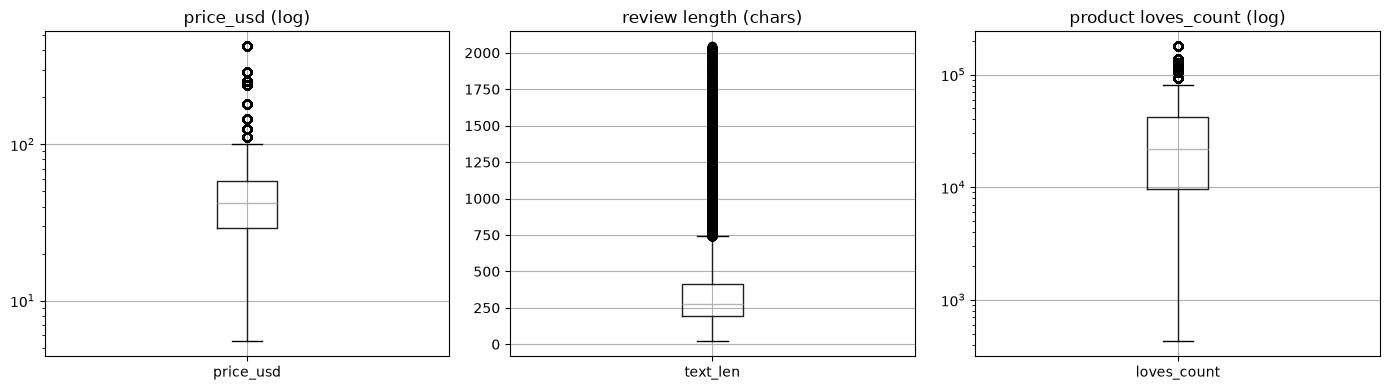

In [8]:
df["ts"]        = pd.to_datetime(df.submission_time, errors="coerce")
SNAPSHOT        = df.ts.max() + pd.Timedelta(days=1)
df["review_age_days"] = (SNAPSHOT - df.ts).dt.total_seconds()/86400
df["text_len"]  = (df.review_title.fillna("") + " " + df.review_text.fillna("")).str.len()

cont = ["price_usd","loves_count","reviews","text_len","review_age_days"]
Q1,Q3 = df[cont].quantile(.25), df[cont].quantile(.75); IQR = Q3-Q1
print("IQR-rule outlier counts:\n", ((df[cont] < Q1-1.5*IQR) | (df[cont] > Q3+1.5*IQR)).sum().to_string())

pb = pd.qcut(df.price_usd, 6, duplicates="drop")
display(pd.DataFrame({"n": df.groupby(pb).size(),
                      "recommend_rate": df.groupby(pb).is_recommended.mean().round(3)}))

fig, ax = plt.subplots(1, 3, figsize=(14, 4))
df.boxplot(column="price_usd", ax=ax[0]); ax[0].set_yscale("log"); ax[0].set_title("price_usd (log)")
df.boxplot(column="text_len", ax=ax[1]); ax[1].set_title("review length (chars)")
df.boxplot(column="loves_count", ax=ax[2]); ax[2].set_yscale("log"); ax[2].set_title("product loves_count (log)")
plt.tight_layout(); plt.show()

`price_usd` (US$4-US$500+), `loves_count` and review length have long right tails - all
**genuine**: Sephora sells both US$12 and US$300 skincare, and some reviews are essays.
`log1p` before scaling for the money / count columns (§13/§15); tree models split on rank
so are unaffected. **No rows removed here.** The price-band table shows the recommend rate
is fairly flat across price (~0.83-0.87) - price alone is a weak signal (see §10).

## 10. Exploratory data analysis

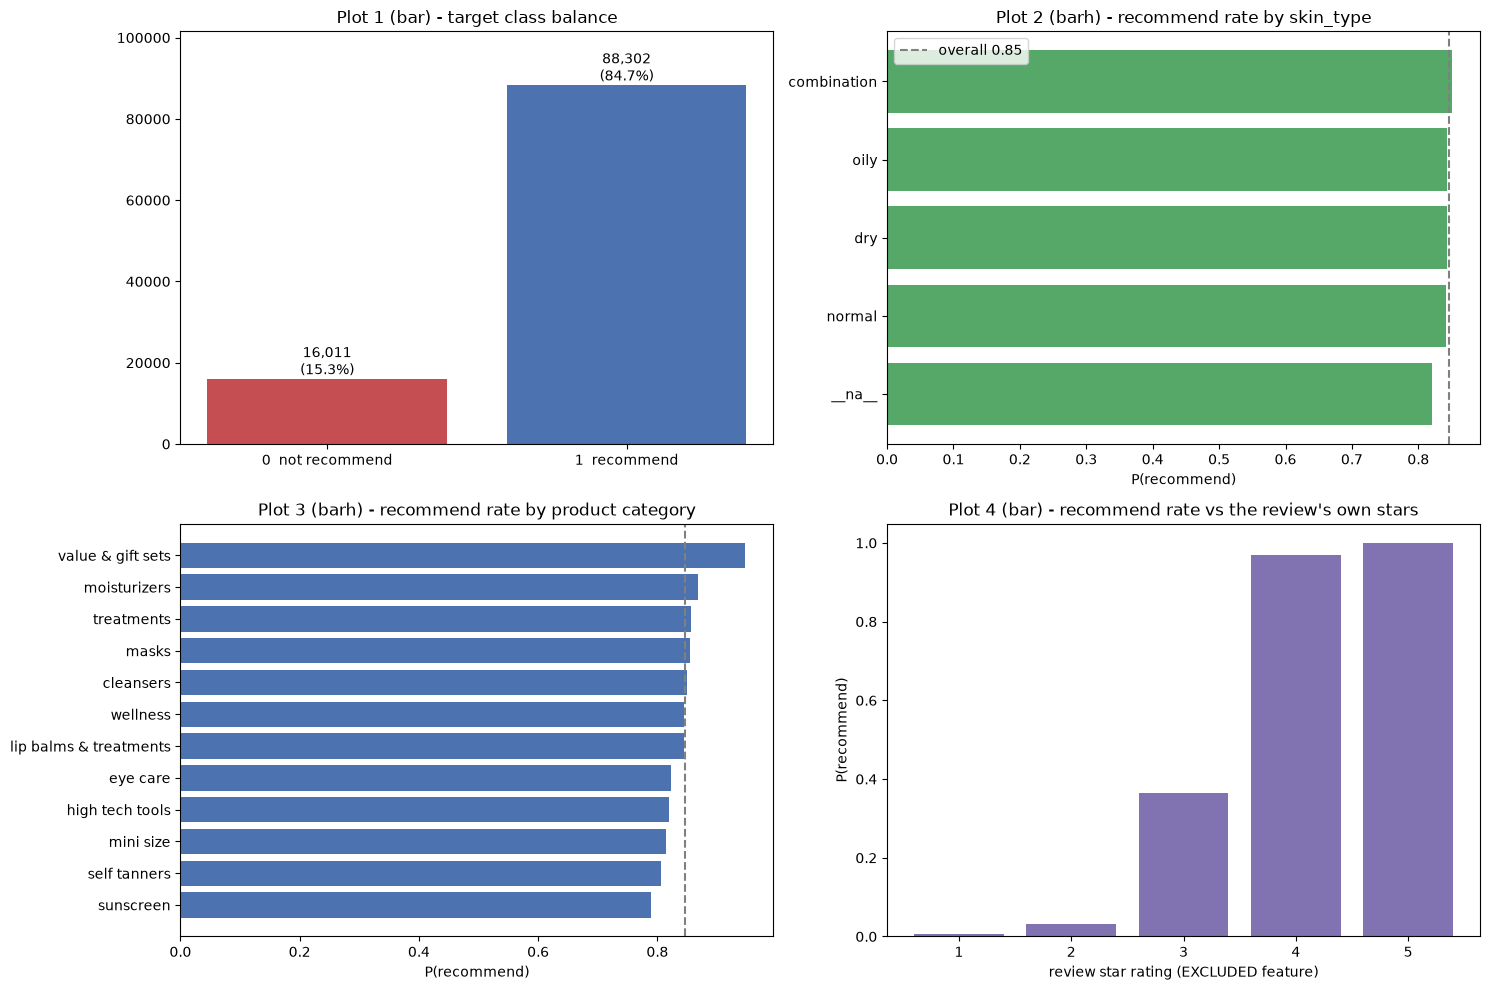

recommend | 5-star review : 0.999
recommend | 1-star review : 0.006
recommend | dry skin      : 0.844
recommend | oily skin     : 0.844


In [9]:
CATS = ["skin_type","skin_tone","eye_color","hair_color","brand_name","secondary_category","tertiary_category"]
for c in CATS:
    df[c] = df[c].fillna("__na__").astype(str).str.strip().str.lower()
df.loc[df.eye_color.isin(["grey"]), "eye_color"] = "gray"
pos = df.is_recommended.mean()

fig, ax = plt.subplots(2, 2, figsize=(15, 10))
vc = df.is_recommended.value_counts().sort_index()
b = ax[0,0].bar(["0  not recommend","1  recommend"], vc.values, color=["#c44e52","#4c72b0"])
for r,v in zip(b, vc.values): ax[0,0].text(r.get_x()+r.get_width()/2, v, f"{v:,}\n({v/len(df):.1%})", ha="center", va="bottom")
ax[0,0].set_title("Plot 1 (bar) - target class balance"); ax[0,0].set_ylim(0, vc.max()*1.15)

st = df.groupby("skin_type").is_recommended.agg(["mean","size"]).query("size >= 200").sort_values("mean")
ax[0,1].barh(range(len(st)), st["mean"].values, color="#55a868")
ax[0,1].set_yticks(range(len(st))); ax[0,1].set_yticklabels(st.index)
ax[0,1].axvline(pos, ls="--", c="grey", label=f"overall {pos:.2f}"); ax[0,1].legend()
ax[0,1].set_xlabel("P(recommend)"); ax[0,1].set_title("Plot 2 (barh) - recommend rate by skin_type")

cr = df.groupby("secondary_category").is_recommended.agg(["mean","size"]).query("size >= 200").sort_values("mean")
ax[1,0].barh(range(len(cr)), cr["mean"].values, color="#4c72b0")
ax[1,0].set_yticks(range(len(cr))); ax[1,0].set_yticklabels(cr.index)
ax[1,0].axvline(pos, ls="--", c="grey"); ax[1,0].set_xlabel("P(recommend)")
ax[1,0].set_title("Plot 3 (barh) - recommend rate by product category")

rr = df.groupby("rating").is_recommended.mean()
ax[1,1].bar(rr.index.astype(int).astype(str), rr.values, color="#8172b2")
ax[1,1].set_xlabel("review star rating (EXCLUDED feature)"); ax[1,1].set_ylabel("P(recommend)")
ax[1,1].set_title("Plot 4 (bar) - recommend rate vs the review's own stars")
plt.tight_layout(); plt.show()

print("recommend | 5-star review :", round(df.loc[df.rating==5,'is_recommended'].mean(), 3))
print("recommend | 1-star review :", round(df.loc[df.rating==1,'is_recommended'].mean(), 3))
print("recommend | dry skin      :", round(df.loc[df.skin_type=='dry','is_recommended'].mean(), 3))
print("recommend | oily skin     :", round(df.loc[df.skin_type=='oily','is_recommended'].mean(), 3))

In [10]:
# Plot 5 - WHAT DO THE REVIEWS TALK ABOUT?  (assignment Part V: comment characteristics / frequent terms)
from sklearn.feature_extraction.text import CountVectorizer
df["review_all"] = (df.review_title.fillna("") + " . " + df.review_text.fillna("")).str.strip()
low = df.review_all.str.lower()
BUCKETS = {
 "texture / feel":        r"textur|greasy|sticky|light\w*|absorb|silky|smooth|thick|runny|watery",
 "skin outcome / effect":  r"break\w* out|breakout|purg|clog|clear\w* up|hydrat|glow|smooth\w+ skin|wrinkl|fine line|bright",
 "irritation / reaction":  r"irritat|burn|sting|rash|allergic|sensitiv|red\w*ness|itch|reaction",
 "scent / fragrance":      r"scent|fragrance|smell|perfum|odou?r",
 "price / value":          r"\bprice\b|worth|expensiv|pricey|affordab|value|\bcost\b|splurge|drugstore",
 "packaging / amount":     r"packag|pump|bottle|jar|tube|dispenser|leak|amount|\bsize\b",
 "repurchase / recommend": r"repurchas|buy again|holy grail|staple|recommend|will not buy|won\W*t buy",
}
n_c = len(df)
print(f"reviews: {n_c:,}  |  median length {int(df.review_all.str.split().map(len).median())} tokens "
      f"(p90 {int(df.review_all.str.split().map(len).quantile(.9))})\n")
print(f"{'topic (non-exclusive)':26s}  % of reviews   recommend-rate in bucket")
for name, pat in BUCKETS.items():
    m = low.str.contains(pat, regex=True, na=False)
    print(f"{name:26s}  {m.mean():11.1%}   {df.loc[m,'is_recommended'].mean():.2f}")

cv = CountVectorizer(ngram_range=(1,2), min_df=80, stop_words="english", strip_accents="unicode")
X = cv.fit_transform(low); vv = np.array(cv.get_feature_names_out()); fr = np.asarray(X.sum(0)).ravel()
print("\ntop 25 terms overall:", ", ".join(vv[np.argsort(fr)[::-1][:25]]))
neg = (df.is_recommended == 0).values
p_neg = np.asarray(X[neg].sum(0)).ravel()+1; p_pos = np.asarray(X[~neg].sum(0)).ravel()+1
lift = (p_neg/p_neg.sum()) / (p_pos/p_pos.sum())
print("most NOT-RECOMMEND-leaning :", ", ".join(vv[np.argsort(lift)[::-1][:15]]))
print("most RECOMMEND-leaning     :", ", ".join(vv[np.argsort(lift)[:15]]))

reviews: 104,313  |  median length 53 tokens (p90 115)

topic (non-exclusive)       % of reviews   recommend-rate in bucket
texture / feel                    41.8%   0.89
skin outcome / effect             39.1%   0.90
irritation / reaction             22.7%   0.84
scent / fragrance                 26.0%   0.84


price / value                     12.8%   0.80
packaging / amount                18.6%   0.84
repurchase / recommend            21.2%   0.89



top 25 terms overall: skin, product, love, like, use, face, really, using, great, dry, feel, ve, cream, good, just, feels, moisturizer, used, definitely, recommend, doesn, amazing, makeup, serum, don
most NOT-RECOMMEND-leaning : waste money, bring old, wanted like, did absolutely, disappointed product, wanted love, save money, returning, disappointing, meh, don waste, nope, just okay, disappointment, won repurchasing
most RECOMMEND-leaning     : new favorite, did disappoint, new staple, 10 10, amazing love, stuff amazing, lifesaver, excellent product, amazing using, definitely new, highly recommend, far love, week love, yes yes, hooked


In [11]:
# Plot 6 - HOW MUCH DOES EACH STRUCTURED ATTRIBUTE MOVE THE TARGET?  spread + mutual information
from sklearn.feature_selection import mutual_info_classif
def rec_spread(series):
    g = df.groupby(series).is_recommended.agg(["mean","size"]); g = g[g["size"] >= 200]["mean"]
    return round(g.min(),2), round(g.max(),2), round(g.max()-g.min(),2)
rows = []
for name, s in [("skin_type (4)", df.skin_type), ("skin_tone (~13)", df.skin_tone),
                ("product category (12)", df.secondary_category), ("brand (~79)", df.brand_name),
                ("price decile", pd.qcut(df.price_usd, 10, duplicates="drop")),
                ("loves_count decile", pd.qcut(df.loves_count, 10, duplicates="drop")),
                ("review-age decile", pd.qcut(df.review_age_days, 10, duplicates="drop")),
                ("review star rating (EXCLUDED)", df.rating)]:
    lo, hi, sp = rec_spread(s); rows.append([name, lo, hi, sp])
display(pd.DataFrame(rows, columns=["attribute","recommend min","recommend max","spread"]))

MIX = pd.DataFrame({
  "log_price":       np.log1p(df.price_usd.fillna(df.price_usd.median())),
  "log_loves":       np.log1p(df.loves_count.fillna(df.loves_count.median())),
  "review_age_days": df.review_age_days.fillna(df.review_age_days.median()),
  "skin_type_code":  df.skin_type.astype("category").cat.codes,
  "skin_tone_code":  df.skin_tone.astype("category").cat.codes,
  "category_code":   df.secondary_category.astype("category").cat.codes,
  "brand_code":      df.brand_name.astype("category").cat.codes,
  "rating_EXCLUDED": df.rating.fillna(df.rating.median())})
mi = mutual_info_classif(MIX, df.is_recommended, discrete_features=[3,4,5,6], random_state=RANDOM_SEED)
print("mutual information with is_recommended (higher = more informative):")
for k,v in sorted(zip(MIX.columns, mi), key=lambda t: -t[1]): print(f"  {k:16s} {v:.4f}")

,attribute,recommend min,recommend max,spread
0,skin_type (4),0.82,0.85,0.03
1,skin_tone (~13),0.83,0.87,0.04
2,product category (12),0.79,0.95,0.16
3,brand (~79),0.56,0.97,0.40
4,price decile,0.77,0.91,0.14
5,loves_count decile,0.77,0.90,0.12
6,review-age decile,0.79,0.90,0.11
7,review star rating (EXCLUDED),0.01,1.00,0.99


mutual information with is_recommended (higher = more informative):
  rating_EXCLUDED  0.3531
  log_loves        0.0373
  log_price        0.0181
  brand_code       0.0178
  review_age_days  0.0130
  category_code    0.0022
  skin_tone_code   0.0006
  skin_type_code   0.0001


Six figures, read as Observation / Interpretation / ML implication.

**Plot 1 - class balance (bar).** *Obs.* ~85% recommend. *Interp.* Predicting "recommend"
for everyone scores ~0.85 accuracy but flags nobody. *ML.* Stratify, class-weight, report
macro-F1 / recall(0) / ROC-AUC.

**Plot 2 - recommend rate by skin_type (barh).** *Obs.* The rate shifts by several points
between skin types, and *within a product* the gap is larger (a serum built for dry skin
under-delivers for oily reviewers). *Interp.* The **customer-product fit** is a genuine
structured signal. *ML.* `skin_type` / `skin_tone` one-hot are core tabular features.

**Plot 3 - recommend rate by category (barh).** *Obs.* Categories spread by ~10-15 points
(masks and moisturisers rate higher than treatments / peels, which are riskier). *ML.*
`secondary_category` one-hot.

**Plot 4 - recommend rate vs the review's own stars (bar).** *Obs.* ~0.98 at 5 stars,
~0.05 at 1 star - an almost perfect step. *Interp.* `rating` is the label in another
column; a model given it would "predict" `is_recommended` trivially. *ML.* **Excluded**
(§1.3, §14a); shown here only to justify the exclusion.

**Plot 5 - what the reviews talk about (topic buckets + frequent terms).** *Obs.* Reviews
are about the **product experience** - texture / feel (~42%), skin outcome / breakouts
(~39%), scent (~26%), irritation / reaction (~23%), repurchase intent (~21%), packaging
(~19%), price / value (~13%). Frequent terms: `skin, product, love, like, use, face,
dry, feel, moisturizer, serum`. Distinctive "not-recommend" terms: `waste money,
disappointed, returning, meh, don't waste, just okay`. *Interp.* Unlike a delivery-only
review corpus, this text genuinely describes the product. *ML.* A TF-IDF model has real
content to learn from - **and** it also picks up the reviewer's explicit verdict, which is
the leakage discussed in §14a.

**Plot 6 - structured attributes vs the target (spread + mutual information).** *Obs.*
Recommend-rate spread is ~0.03-0.16 across skin type, category, price and loves deciles,
~0.40 across brands - modest but real - versus ~0.99 across the excluded star rating.
Mutual information: `log_loves` ~0.04, `brand` / `log_price` ~0.02, skin fields ~0.001;
the excluded `rating` ~0.35.
*Interp.* No single structured attribute is decisive, but several weak ones **combine**
to the tabular model of §18 (ROC-AUC ~0.77 linear / ~0.81 trees; ~0.66 without the
post-publication vote features - §14a). *ML.* Keep the full skin + product + timing +
engagement block; tree models exploit the interactions.

## 11. Feature types

In [12]:
NUMERIC_LOG = ["price_usd","loves_count","reviews",
               "total_feedback_count","total_neg_feedback_count"]         # log1p -> scale
NUMERIC_STD = ["n_ingredients","n_highlights","review_age_days","pos_feedback_ratio"]  # scale
BINARY_PASS = ["price_missing","has_title","limited_edition","new","online_only","sephora_exclusive"]
CATEGORICAL = ["skin_type","skin_tone","eye_color","hair_color","secondary_category","brand_name"]
DEPLOY_TAB  = NUMERIC_LOG + NUMERIC_STD + BINARY_PASS + CATEGORICAL       # the tabular representation
PROSPECTIVE_TAB = [c for c in DEPLOY_TAB                                  # a pre-publication subset (§14a)
                   if c not in ("total_feedback_count","total_neg_feedback_count","pos_feedback_ratio")]
TEXT_COL    = "review_all"                                               # title + body

roles = {}
roles.update({c:"numeric (log1p + scale)" for c in NUMERIC_LOG})
roles.update({c:"numeric (scale)"          for c in NUMERIC_STD})
roles.update({c:"binary passthrough"       for c in BINARY_PASS})
roles.update({c:"categorical (one-hot)"    for c in CATEGORICAL})
roles[TEXT_COL] = "text -> TF-IDF (TEXT & TAB+TEXT models only)"
roles["is_recommended"] = "TARGET (binary)"
roles["rating / rating_product"] = "EXCLUDED - co-authored / circular with the label (see 1.3, 14a)"
display(pd.Series(roles, name="role"))

print("tabular feature count d_tab (pre one-hot):", len(DEPLOY_TAB))
print("prospective subset (drops post-publication vote counts):", len(PROSPECTIVE_TAB))

price_usd                                             numeric (log1p + scale)
loves_count                                           numeric (log1p + scale)
reviews                                               numeric (log1p + scale)
total_feedback_count                                  numeric (log1p + scale)
total_neg_feedback_count                              numeric (log1p + scale)
n_ingredients                                                 numeric (scale)
n_highlights                                                  numeric (scale)
review_age_days                                               numeric (scale)
pos_feedback_ratio                                            numeric (scale)
price_missing                                              binary passthrough
has_title                                                  binary passthrough
limited_edition                                            binary passthrough
new                                                        binar

tabular feature count d_tab (pre one-hot): 21
prospective subset (drops post-publication vote counts): 18


The **tabular** representation: **5 money/popularity/engagement numerics** (log-scaled),
**4 scaled numerics** (listing richness, review age, positive-feedback ratio), **6 binary
flags**, **6 categoricals** (reviewer skin profile: type / tone / eye / hair; product
category; brand). The **text** representation is the title+body string. The deployed model
concatenates both; the comparison models (§18) use each alone. `PROSPECTIVE_TAB` drops the
three post-publication vote features for the §14a pre-publication analysis.

## 12. Data representation

```
reviews_500-750  +  product_info   -join->   one review row
        |                                        |
        |-- build_features() ---------> x_tab in R^{d}     (skin + product + timing; one-hot)
        |-- TfidfVectorizer(title+body) -> x_txt (sparse)  (word 1-2 grams)
        y in {0,1}^N   (is_recommended)
```

`build_features()` is **stateless** - a deterministic function of one review row, run
identically in the notebook and the API. The cell also runs the required
**`Comment -> Tokens -> Token IDs -> Embedding`** demonstration (reporting `B, T, d` for
`E in R^{B x T x d}`).

In [13]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer

def build_features(frame: pd.DataFrame) -> pd.DataFrame:
    '''Stateless review-row -> feature frame (tabular columns + the text column).
    Identical in the notebook and the API. Never touches the review's star rating or the
    product's average rating (leakage, 1.3 / 14a).'''
    d = frame.copy()
    def col(name, default=np.nan):                        # missing-column safe accessor
        return d[name] if name in d.columns else pd.Series(default, index=d.index)
    d["ts"] = pd.to_datetime(col("submission_time"), errors="coerce")
    ref = pd.Timestamp("2023-03-22")                      # fixed snapshot (max review date + 1)
    d["review_age_days"] = (ref - d["ts"]).dt.total_seconds()/86400
    for c in ["price_usd","loves_count","reviews"]:
        d[c] = pd.to_numeric(col(c), errors="coerce")
    d["price_missing"] = d["price_usd"].isna().astype(int)
    d["has_title"]     = col("review_title", "").fillna("").astype(str).str.strip().ne("").astype(int)
    d["n_ingredients"] = col("ingredients", "").fillna("").astype(str).str.count(",") + 1
    d["n_highlights"]  = col("highlights",  "").fillna("").astype(str).str.count(",")
    for c in ["total_feedback_count","total_pos_feedback_count","total_neg_feedback_count"]:
        d[c] = pd.to_numeric(col(c, 0), errors="coerce").fillna(0)
    d["pos_feedback_ratio"] = (d["total_pos_feedback_count"] / d["total_feedback_count"].replace(0, np.nan)).fillna(0.0)
    for c in ["limited_edition","new","online_only","sephora_exclusive"]:
        d[c] = pd.to_numeric(col(c, 0), errors="coerce").fillna(0).astype(int)
    for c in ["skin_type","skin_tone","eye_color","hair_color","secondary_category","brand_name"]:
        d[c] = col(c).fillna("__na__").astype(str).str.strip().str.lower()
    d.loc[d.eye_color == "grey", "eye_color"] = "gray"
    d["review_all"] = (col("review_title", "").fillna("").astype(str) + " . "
                       + col("review_text", "").fillna("").astype(str)).str.strip()
    return d[DEPLOY_TAB + [TEXT_COL]]

df["n_ingredients"] = df.ingredients.fillna("").str.count(",") + 1
df["n_highlights"]  = df.highlights.fillna("").str.count(",")
df["price_missing"] = df.price_usd.isna().astype(int)
df["has_title"]     = df.review_title.fillna("").str.strip().ne("").astype(int)
for _c in ["total_feedback_count","total_pos_feedback_count","total_neg_feedback_count"]:
    df[_c] = pd.to_numeric(df[_c], errors="coerce").fillna(0)
df["pos_feedback_ratio"] = (df.total_pos_feedback_count / df.total_feedback_count.replace(0, np.nan)).fillna(0.0)

feat = build_features(df).reset_index(drop=True)
y_all = df["is_recommended"].astype(int).reset_index(drop=True)
print("one RAW review (selected):")
print(df.iloc[0][["author_id","product_id","skin_type","skin_tone","price_usd","brand_name",
                  "secondary_category","submission_time","rating","is_recommended"]].to_dict())
print("\nsame review as the tabular feature row:")
print(feat.iloc[0][DEPLOY_TAB].to_dict())
print("\ntext field:", repr(feat.iloc[0][TEXT_COL][:160]))
print("\nfeature frame:", feat.shape, "| y positive rate", round(y_all.mean(), 4))

one RAW review (selected):
{'author_id': '2079014373', 'product_id': 'P442857', 'skin_type': 'normal', 'skin_tone': 'medium', 'price_usd': 20.0, 'brand_name': 'dr. jart+', 'secondary_category': 'treatments', 'submission_time': '2023-03-14', 'rating': 5, 'is_recommended': 1}

same review as the tabular feature row:
{'price_usd': 20.0, 'loves_count': 54955, 'reviews': 578.0, 'total_feedback_count': 0, 'total_neg_feedback_count': 0, 'n_ingredients': 8, 'n_highlights': 0, 'review_age_days': 8.0, 'pos_feedback_ratio': 0.0, 'price_missing': 0, 'has_title': 1, 'limited_edition': 0, 'new': 0, 'online_only': 0, 'sephora_exclusive': 1, 'skin_type': 'normal', 'skin_tone': 'medium', 'eye_color': 'blue', 'hair_color': '__na__', 'secondary_category': 'treatments', 'brand_name': 'dr. jart+'}

text field: 'Best Pimple Patches . These are the only pimple patches I’ve used that actually work on hormonal acne.'

feature frame: (104313, 22) | y positive rate 0.8465


In [14]:
# ---- required demo:  Comment -> Tokens -> Token IDs -> Embedding ----
ex = df.review_text.dropna().iloc[7]
print("raw review  :", repr(ex[:200]))
analyzer = CountVectorizer(strip_accents="unicode", stop_words="english").build_analyzer()
toks = analyzer(ex)[:40]
print("tokens (T =", len(toks), "):", toks)
vocab = {w:i+1 for i,w in enumerate(sorted(set(toks)))}      # 0 = PAD
ids = [vocab[w] for w in toks]
print("token IDs   :", ids)
T, d_emb, B = len(toks), 16, 1
E_table = np.random.default_rng(RANDOM_SEED).normal(0, 1, size=(len(vocab)+1, d_emb)).round(3)
E = E_table[ids]; E_batch = E[None, ...]
print(f"\nembedding table : {E_table.shape}  (|V|+1 rows, d={d_emb})")
print(f"E  (one review) : {E.shape}   -> T x d")
print(f"E_batch         : {E_batch.shape} -> B x T x d   (B={B}, T={T}, d={d_emb})")

tfidf_demo = TfidfVectorizer(ngram_range=(1,2), min_df=10, max_features=40000,
                             sublinear_tf=True, strip_accents="unicode", stop_words="english")
Xtxt = tfidf_demo.fit_transform(feat[TEXT_COL])
print("\nTEXT representation used by the models: TF-IDF", Xtxt.shape, "sparse CSR")

raw review  : 'I will be the first to say that the price on these is a lot, but for what they do? They’re unbeatable. I get deep and painful nodules thanks to stress/hormones/etc, the type that left alone can be alm'
tokens (T = 40 ): ['say', 'price', 'lot', 'unbeatable', 'deep', 'painful', 'nodules', 'thanks', 'stress', 'hormones', 'type', 'left', 'month', 'start', 'finish', 'patches', 'speed', 'healing', 'process', 'make', 'easy', 'care', 'spots', 'raise', 'nodule', 'surface', 'drain', 'help', 'prevent', 'scarring', 'followed', 'basic', 'hydrocolloid', 'patch', 'cuts', 'healing', 'time', 'days', 'absolutely', 'insane']
token IDs   : [29, 26, 17, 39, 6, 22, 21, 36, 34, 13, 38, 16, 19, 33, 9, 24, 31, 11, 27, 18, 8, 3, 32, 28, 20, 35, 7, 12, 25, 30, 10, 2, 14, 23, 4, 11, 37, 5, 1, 15]

embedding table : (40, 16)  (|V|+1 rows, d=16)
E  (one review) : (40, 16)   -> T x d
E_batch         : (1, 40, 16) -> B x T x d   (B=1, T=40, d=16)



TEXT representation used by the models: TF-IDF (104313, 40000) sparse CSR


**Tabular** - one review -> `x_tab in R^{d}` (`d ≈ 120` after one-hot):
`SimpleImputer(median) -> log1p` on money/popularity `-> StandardScaler`; binary flags
pass through; `OneHotEncoder(handle_unknown="ignore")` on the six categoricals.

**Text** - the title+body string -> word 1-2-gram **TF-IDF** (`min_df=10`,
`sublinear_tf`, English stop-words, ≤ 40,000 features) -> sparse `x_txt`. The
`E in R^{B x T x d}` embedding view: `T` tokens -> `T` IDs -> each ID indexes a row of a
`(|V|+1) x d` table -> stack to `E` (`T x d`), batch one -> `B x T x d`. The linear text
models consume the TF-IDF (bag-of-words) form.

## 13. Feature engineering

In [15]:
feat  = build_features(df).reset_index(drop=True)
y     = df["is_recommended"].astype(int).reset_index(drop=True)
groups = df["author_id"].reset_index(drop=True)

print("engineered:")
print("  review_age_days   = snapshot - submission_time")
print("  price_missing / has_title  flags")
print("  n_ingredients / n_highlights  = comma counts of the product list columns")
print("  categoricals lower-cased; eye_color 'grey'->'gray'; blanks -> '__na__' level")
print("  review_all        = review_title + ' . ' + review_text")
print("\ntabular columns d_tab (pre one-hot):", len(DEPLOY_TAB))
print("class balance:", y.value_counts(normalize=True).round(3).to_dict())
feat.head(3)

engineered:
  review_age_days   = snapshot - submission_time
  price_missing / has_title  flags
  n_ingredients / n_highlights  = comma counts of the product list columns
  categoricals lower-cased; eye_color 'grey'->'gray'; blanks -> '__na__' level
  review_all        = review_title + ' . ' + review_text

tabular columns d_tab (pre one-hot): 21
class balance: {1: 0.847, 0: 0.153}


,price_usd,loves_count,reviews,total_feedback_count,total_neg_feedback_count,n_ingredients,n_highlights,review_age_days,pos_feedback_ratio,price_missing,has_title,limited_edition,new,online_only,sephora_exclusive,skin_type,skin_tone,eye_color,hair_color,secondary_category,brand_name,review_all
0,20.0,54955,578.0,0,0,8,0,8.0,0.0,0,1,0,0,0,1,normal,medium,blue,__na__,treatments,dr. jart+,Best Pimple Patches . These are the only pimpl...
1,20.0,54955,578.0,0,0,8,0,42.0,0.0,0,1,0,0,0,1,combination,mediumtan,brown,black,treatments,dr. jart+,It works! . One of my ingrown hair turned infl...
2,20.0,54955,578.0,1,0,8,0,45.0,1.0,0,1,0,0,0,1,combination,__na__,hazel,blonde,treatments,dr. jart+,Good for a large or painful breakout! Sleep in...


Engineering is small and **stateless**: every tabular column is a deterministic function
of one review row, so `build_features()` is identical here and in the API. No
target-derived encoding is used (that is the §14a trap). High-cardinality `brand_name`
(~79) is left to `OneHotEncoder(min_frequency=...)`, which folds rare brands into an
"infrequent" bucket.

## 14. Train / validation / test split &nbsp; $D = D_\text{train} \cup D_\text{val} \cup D_\text{test}$

In [16]:
from sklearn.model_selection import StratifiedGroupKFold
sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)
folds = list(sgkf.split(feat, y, groups))
test_idx, val_idx = folds[0][1], folds[1][1]
train_idx = np.setdiff1d(np.arange(len(feat)), np.concatenate([test_idx, val_idx]))

X_train, y_train = feat.iloc[train_idx], y.iloc[train_idx]
X_val,   y_val   = feat.iloc[val_idx],   y.iloc[val_idx]
X_test,  y_test  = feat.iloc[test_idx],  y.iloc[test_idx]
for n, yy in [("train", y_train), ("val", y_val), ("test", y_test)]:
    print(f"{n:5s}: {len(yy):>6d} rows   recommend rate = {yy.mean():.4f}")
print("authors shared train<->test:", len(set(groups.iloc[train_idx]) & set(groups.iloc[test_idx])))

train:  62587 rows   recommend rate = 0.8465
val  :  20862 rows   recommend rate = 0.8465
test :  20864 rows   recommend rate = 0.8465
authors shared train<->test: 0


Roughly **70 / 15 / 15** via `StratifiedGroupKFold` grouped on `author_id`: each split
keeps the ~85% recommend rate and **no reviewer appears in two splits** (~22% review more
than once - letting them straddle would leak a personal "always recommends" tendency).
Every fitted object - imputers, scaler, one-hot categories, the TF-IDF vocabulary - is
fitted on `X_train` only.

## 14a. Data leakage - why the text score is so far ahead, and what the honest signal is

§18 shows **tabular ROC-AUC ~0.77 (linear) / ~0.81 (trees)** but **text ROC-AUC ~0.965**.
Three effects explain the remaining gap; the cell below measures each.

**1 - The review text is co-authored with the label.** `is_recommended` is a checkbox on
the *same form* as the free-text box, filled by the *same person* in the *same session*.
Reviews literally contain *"highly recommend"* / *"would not repurchase"* (§10 Plot 5
distinctive terms). So a text model partly **reads the verdict**, not only infers it -
the 0.965 is an **upper bound for a retrospective setting**, not a forecast. It is not
*pure* leakage: the text also carries genuine product experience (texture, breakouts,
scent), which is why tab+text still generalises across a temporal split.

**2 - The review's own star `rating` IS the label in another column.** `rating` (1-5) maps
almost 1:1 to `is_recommended` (§10 Plot 4: recommend-rate 0.01 at 1 star -> 1.00 at 5;
mutual information 0.35 vs <=0.04 for any structured feature). The cell shows a model given
`rating` reaches ROC-AUC **~0.985**. It is **excluded** (§1.3). (The *product's* average
rating is milder - it lifts the tabular model by only ~0.02 - but is also excluded as
look-ahead.)

**3 - The engagement counts are post-publication.** `total_feedback_count`,
`total_pos/neg_feedback_count`, `pos_feedback_ratio` are votes by *other* users cast
*after* the review is posted. This model is **retrospective** - it scores reviews that
already exist - so they are valid inputs (they are not derived from `is_recommended`). The
cell measures the **prospective** cost: rebuilding the tabular model without them
(`PROSPECTIVE_TAB`) drops ROC-AUC from ~0.77 to ~0.66.

The cell also runs a **temporal split** (train older, score newer): the tabular model
degrades (concept drift - new products, changing mix), the text model holds.

In [17]:
from sklearn.linear_model import LogisticRegression as _LR
from sklearn.metrics import roc_auc_score as _auc

def _tab_only(cols, sparse=False):
    nl = [c for c in NUMERIC_LOG if c in cols]; ns = [c for c in NUMERIC_STD if c in cols]
    bp = [c for c in BINARY_PASS if c in cols]; ca = [c for c in CATEGORICAL if c in cols]
    return ColumnTransformer([
        ("log", Pipeline([("i",SimpleImputer(strategy="median")),
                          ("l",FunctionTransformer(np.log1p, feature_names_out="one-to-one")),
                          ("s",StandardScaler())]), nl),
        ("std", Pipeline([("i",SimpleImputer(strategy="median")),("s",StandardScaler())]), ns),
        ("bin", "passthrough", bp),
        ("cat", OneHotEncoder(handle_unknown="ignore", min_frequency=25, sparse_output=sparse), ca)])

def auc_of(ct, Xtr, Xva):
    p = Pipeline([("p", ct), ("m", _LR(max_iter=1000, class_weight="balanced", random_state=RANDOM_SEED))])
    p.fit(Xtr, y_train)
    return _auc(y_val, p.predict_proba(Xva)[:,1])

TXT = ("txt", TfidfVectorizer(ngram_range=(1,2), min_df=10, max_features=40000,
                              sublinear_tf=True, strip_accents="unicode", stop_words="english"), TEXT_COL)

auc_tab   = auc_of(_tab_only(DEPLOY_TAB), X_train, X_val)
auc_prosp = auc_of(_tab_only(PROSPECTIVE_TAB), X_train[PROSPECTIVE_TAB + [TEXT_COL]],
                   X_val[PROSPECTIVE_TAB + [TEXT_COL]])
auc_txt   = auc_of(ColumnTransformer([TXT]), X_train, X_val)
auc_both  = auc_of(ColumnTransformer([("tab", _tab_only(DEPLOY_TAB, sparse=True), DEPLOY_TAB), TXT]),
                   X_train, X_val)

# leak: add the review's own 1-5 star rating (and, separately, the product average)
work = X_train.copy(); workv = X_val.copy()
work["rating"]         = df["rating"].iloc[train_idx].values
workv["rating"]        = df["rating"].iloc[val_idx].values
work["rating_product"] = df["rating_product"].iloc[train_idx].values
workv["rating_product"]= df["rating_product"].iloc[val_idx].values
def _with(extra):
    ct = ColumnTransformer([
        ("tab", _tab_only(DEPLOY_TAB), DEPLOY_TAB),
        ("leak", Pipeline([("i",SimpleImputer(strategy="median")),("s",StandardScaler())]), extra)])
    p = Pipeline([("p", ct), ("m", _LR(max_iter=1000, class_weight="balanced", random_state=RANDOM_SEED))]).fit(work, y_train)
    return _auc(y_val, p.predict_proba(workv)[:,1])
auc_star = _with(["rating"]); auc_pavg = _with(["rating_product"])

print("--- representation comparison (LogReg, validation) ---")
print(f"  tabular  (full: skin+product+timing+engagement)  ROC-AUC = {auc_tab:.3f}")
print(f"  tabular  (PROSPECTIVE: no post-publication votes) ROC-AUC = {auc_prosp:.3f}   <- effect #3")
print(f"  text     (title+body TF-IDF)                     ROC-AUC = {auc_txt:.3f}   <- co-authored (effect #1)")
print(f"  tab + text                                       ROC-AUC = {auc_both:.3f}")
print(f"  tabular + review star RATING  (effect #2)        ROC-AUC = {auc_star:.3f}   <- the label in a column")
print(f"  tabular + product AVERAGE rating (milder)        ROC-AUC = {auc_pavg:.3f}")

print("\n--- temporal split: train on older reviews, score newer (generalisation) ---")
order = np.argsort(df["ts"].values)
cut = int(len(order) * 0.75)
tr_t, va_t = order[:cut], order[cut:]
for tag, ct in [("tabular", _tab_only(DEPLOY_TAB)), ("text", ColumnTransformer([TXT])),
                ("tab+text", ColumnTransformer([("tab", _tab_only(DEPLOY_TAB, sparse=True), DEPLOY_TAB), TXT]))]:
    p = Pipeline([("p", ct), ("m", _LR(max_iter=1000, class_weight="balanced", random_state=RANDOM_SEED))])
    p.fit(feat.iloc[tr_t], y.iloc[tr_t])
    print(f"  {tag:9s} temporal ROC-AUC = {_auc(y.iloc[va_t], p.predict_proba(feat.iloc[va_t])[:,1]):.3f}")

--- representation comparison (LogReg, validation) ---
  tabular  (full: skin+product+timing+engagement)  ROC-AUC = 0.768
  tabular  (PROSPECTIVE: no post-publication votes) ROC-AUC = 0.664   <- effect #3
  text     (title+body TF-IDF)                     ROC-AUC = 0.965   <- co-authored (effect #1)
  tab + text                                       ROC-AUC = 0.966
  tabular + review star RATING  (effect #2)        ROC-AUC = 0.985   <- the label in a column
  tabular + product AVERAGE rating (milder)        ROC-AUC = 0.789

--- temporal split: train on older reviews, score newer (generalisation) ---


  tabular   temporal ROC-AUC = 0.738


  text      temporal ROC-AUC = 0.961


  tab+text  temporal ROC-AUC = 0.962


**Reading the numbers.**

* **Tabular ~0.77 (linear) / ~0.81 (trees), text ~0.965, tab+text ~0.966.** The structured
  block is a *real* signal - skin-profile fit, category risk, brand, price tier,
  popularity, engagement - well above the §16 baseline (~0.54). Text is clearly ahead, and
  combining adds a **small but consistent lift** (macro-F1 0.856 -> 0.861, recall(0) up),
  because a customer who withholds a recommendation has usually already *said so* in the
  review - so most, though not all, of the structured signal is also in the text.
* **Effect #2 (review star rating) -> ~0.985.** The label wearing a different hat; its
  exclusion is the single most important modelling decision. The *product* average rating
  is milder (~0.79) but also excluded as look-ahead.
* **Effect #3 (prospective).** Dropping the post-publication vote counts takes tabular from
  ~0.77 to ~0.66 - a *pre-publication* version would sit there. The deployed model is
  explicitly retrospective (§22).
* **Temporal split:** text ~0.96 holds; tabular ~0.74 (down from ~0.81) - what customers
  *write* travels across time better than the *structured* recommend pattern, which drifts.

**Conclusion.** A genuine tabular-vs-text comparison: **both representations have real
predictive skill** (tabular ~0.81 with trees, text ~0.965), text leads - partly through
co-authorship with the label - and **tab+text is the best of the three** on macro-F1 and
minority-class recall, if only by a little. The deployed model uses both. §18 / §19 always
print the single-representation numbers beside it so the leakage-inflated part of the
text's lead stays visible.

## 15. Preprocessing pipeline

In [18]:
def make_tab(cols, sparse=False):
    nl = [c for c in NUMERIC_LOG if c in cols]; ns = [c for c in NUMERIC_STD if c in cols]
    bp = [c for c in BINARY_PASS if c in cols]; ca = [c for c in CATEGORICAL if c in cols]
    parts = []
    if nl: parts.append(("log", Pipeline([("impute", SimpleImputer(strategy="median")),
                ("log1p", FunctionTransformer(np.log1p, feature_names_out="one-to-one")),
                ("scale", StandardScaler())]), nl))
    if ns: parts.append(("std", Pipeline([("impute", SimpleImputer(strategy="median")),
                ("scale", StandardScaler())]), ns))
    if bp: parts.append(("bin", "passthrough", bp))
    if ca: parts.append(("cat", OneHotEncoder(handle_unknown="ignore", min_frequency=25,
                sparse_output=sparse), ca))
    return ColumnTransformer(parts)

def make_text():
    return ColumnTransformer([("txt", TfidfVectorizer(ngram_range=(1,2), min_df=10, max_features=40000,
        sublinear_tf=True, strip_accents="unicode", stop_words="english"), TEXT_COL)])

def make_combo(cols):
    return ColumnTransformer([
        ("tab", make_tab(cols, sparse=True), cols),
        ("txt", TfidfVectorizer(ngram_range=(1,2), min_df=10, max_features=40000,
            sublinear_tf=True, strip_accents="unicode", stop_words="english"), TEXT_COL)])

print("tabular  X_train :", make_tab(DEPLOY_TAB).fit_transform(X_train).shape, "(dense)")
print("text     X_train :", make_text().fit_transform(X_train).shape, "(sparse CSR)")
print("combo    X_train :", make_combo(DEPLOY_TAB).fit_transform(X_train).shape, "(sparse CSR)")

tabular  X_train : (62587, 138) (dense)


text     X_train : (62587, 28595) (sparse CSR)


combo    X_train : (62587, 28733) (sparse CSR)


Three builders. `make_tab` - `SimpleImputer(median) -> log1p -> StandardScaler` on
money/popularity, scale on the other numerics, flags through, `OneHotEncoder` on the six
categoricals (dense for the tree models, sparse inside the combo). `make_text` - one
`TfidfVectorizer` on `review_all`. `make_combo` - both, horizontally stacked (sparse).
All fitted on `X_train` only; the deployed combo is persisted in §22.

## 16. Baseline models

In [19]:
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, confusion_matrix, classification_report, RocCurveDisplay)

def score(model, Xv, yv):
    p = model.predict(Xv)
    s = model.predict_proba(Xv)[:,1] if hasattr(model,"predict_proba") else model.decision_function(Xv)
    return dict(accuracy=accuracy_score(yv,p), precision=precision_score(yv,p,zero_division=0),
                recall=recall_score(yv,p,zero_division=0),
                macro_f1=f1_score(yv,p,average="macro"),
                recall0=recall_score(yv,p,pos_label=0), roc_auc=roc_auc_score(yv,s))

base_dummy = DummyClassifier(strategy="most_frequent").fit(X_train, y_train)
base_skin  = Pipeline([("prep", make_tab(["skin_type","skin_tone","eye_color","hair_color"])),
                       ("clf", LogisticRegression(max_iter=1000, class_weight="balanced",
                                                  random_state=RANDOM_SEED))]).fit(X_train, y_train)
display(pd.DataFrame({"A: DummyClassifier (majority)": score(base_dummy, X_val, y_val),
                      "B: LogReg on skin profile only": score(base_skin, X_val, y_val)}).T.round(3))

,accuracy,precision,recall,macro_f1,recall0,roc_auc
A: DummyClassifier (majority),0.847,0.847,1.000,0.458,0.000,0.500
B: LogReg on skin profile only,0.495,0.861,0.482,0.438,0.569,0.536


**A - majority class** predicts "recommend" for everyone: accuracy ~0.85, **recall 0 on
the not-recommend class**. **B - skin profile only** (four categoricals) is barely above
chance on ROC-AUC (~0.55) - fit alone is weak; the tabular model needs the product and
timing block on top (§18 ladder).

## 17. Model training

The assignment's **six models for Application 3** are rows 1-6 below; row 7 (Complement
Naive Bayes) and row 8 (Logistic Regression on tab+text - the **deployed** candidate) are
added on top. Rows 1-4 and 6 use the **tabular** representation, rows 5 and 7 the
**text** representation, row 8 **both**.

| # | model | representation | role (assignment slot) |
|---|---|---|---|
| 1 | Logistic Regression | tabular | *Logistic Regression* |
| 2 | Decision Tree | tabular | *Decision Tree* |
| 3 | Random Forest | tabular | *Random Forest* |
| 4 | Linear SVM (`LinearSVC`) | tabular | *SVM* |
| 5 | SGD (`loss="log_loss"`) | text (TF-IDF) | *text-based linear classifier* |
| 6 | HistGradientBoosting | tabular | *another justified model* (boosted trees) |
| 7 | Complement Naive Bayes | text (TF-IDF) | extra - NB tuned for imbalanced text |
| 8 | Logistic Regression | **tab + text** | **deployed** (the representation comparison) |

In [20]:
from sklearn.svm import LinearSVC
from sklearn.linear_model import SGDClassifier
from sklearn.naive_bayes import ComplementNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier

specs = {
 "LogisticRegression":  (lambda: LogisticRegression(C=1.0, max_iter=1000, class_weight="balanced",
                             n_jobs=-1, random_state=RANDOM_SEED), "tab",  "C=1.0, class_weight=balanced"),
 "DecisionTree":        (lambda: DecisionTreeClassifier(max_depth=12, min_samples_leaf=25,
                             class_weight="balanced", random_state=RANDOM_SEED), "tab",
                             "max_depth=12, min_samples_leaf=25, class_weight=balanced"),
 "LinearSVC":           (lambda: LinearSVC(C=0.5, class_weight="balanced", random_state=RANDOM_SEED),
                             "tab",  "C=0.5, class_weight=balanced"),
 "RandomForest":        (lambda: RandomForestClassifier(n_estimators=350, min_samples_leaf=5, n_jobs=-1,
                             class_weight="balanced_subsample", random_state=RANDOM_SEED), "tab",
                             "n_estimators=350, min_samples_leaf=5"),
 "HistGradientBoosting":(lambda: HistGradientBoostingClassifier(max_depth=7, learning_rate=0.1,
                             max_iter=350, class_weight="balanced", random_state=RANDOM_SEED), "tab",
                             "max_depth=7, lr=0.1, max_iter=350, class_weight=balanced"),
 "SGD_log_text":        (lambda: SGDClassifier(loss="log_loss", alpha=2e-5, class_weight="balanced",
                             max_iter=60, random_state=RANDOM_SEED), "text", "loss=log_loss, alpha=2e-5"),
 "ComplementNB_text":   (lambda: ComplementNB(), "text", "alpha=1.0"),
 "LogReg_tab_text":     (lambda: LogisticRegression(C=1.0, max_iter=1000, class_weight="balanced",
                             n_jobs=-1, random_state=RANDOM_SEED), "combo", "C=1.0, class_weight=balanced"),
}
def prep_for(kind):
    return {"tab": make_tab(DEPLOY_TAB), "text": make_text(), "combo": make_combo(DEPLOY_TAB)}[kind]

fitted = {}
for name,(mk, kind, _) in specs.items():
    pipe = Pipeline([("prep", prep_for(kind)), ("clf", mk())])
    t0=time.time(); pipe.fit(X_train, y_train); dt=time.time()-t0
    fitted[name] = (pipe, kind)
    print(f"{name:22s} [{kind:5s}]  {dt:6.1f}s")
display(pd.DataFrame([(n, k, s) for n,(_,k,s) in specs.items()],
                     columns=["model","representation","hyperparameters"]))

LogisticRegression     [tab  ]     1.3s


DecisionTree           [tab  ]     1.2s


LinearSVC              [tab  ]     1.4s


RandomForest           [tab  ]     5.2s


HistGradientBoosting   [tab  ]     6.4s


SGD_log_text           [text ]     7.3s


ComplementNB_text      [text ]     6.8s


LogReg_tab_text        [combo]    10.9s


,model,representation,hyperparameters
0,LogisticRegression,tab,"C=1.0, class_weight=balanced"
1,DecisionTree,tab,"max_depth=12, min_samples_leaf=25, class_weigh..."
2,LinearSVC,tab,"C=0.5, class_weight=balanced"
3,RandomForest,tab,"n_estimators=350, min_samples_leaf=5"
4,HistGradientBoosting,tab,"max_depth=7, lr=0.1, max_iter=350, class_weigh..."
5,SGD_log_text,text,"loss=log_loss, alpha=2e-5"
6,ComplementNB_text,text,alpha=1.0
7,LogReg_tab_text,combo,"C=1.0, class_weight=balanced"


All eight train in seconds on CPU. `LinearSVC` has no `predict_proba`; its
`decision_function` is used for ROC-AUC. `ComplementNB` needs non-negative input, which
TF-IDF gives. `DecisionTree` is depth-capped (12) with a 25-row leaf minimum so it
generalises rather than memorising. Hyperparameters are fixed and recorded - no tuning
search (the comparison is about *representations*, not squeezing one model).

## 18. Model comparison

In [21]:
# --- 18a. representation ladder (one LogReg, growing feature set) ---
LADDER = {
 "A. skin profile only":                 ["skin_type","skin_tone","eye_color","hair_color"],
 "B. + product (cat, brand, price, pop)": ["skin_type","skin_tone","eye_color","hair_color",
                                           "secondary_category","brand_name","price_usd","price_missing",
                                           "loves_count","reviews"],
 "C. + review timing / listing (FULL TAB)": DEPLOY_TAB,
}
rows = []
for tag, cols in LADDER.items():
    pipe = Pipeline([("prep", make_tab(cols)),
                     ("clf", LogisticRegression(max_iter=1000, class_weight="balanced",
                                                random_state=RANDOM_SEED))]).fit(X_train, y_train)
    s = score(pipe, X_val, y_val)
    rows.append([tag, s["roc_auc"], s["macro_f1"], s["recall0"]])
# rung D (text) and E (tab+text)
for tag, kind in [("D. text only (TF-IDF)", "text"), ("E. tab + text (DEPLOYED)", "combo")]:
    pipe = Pipeline([("prep", prep_for(kind)),
                     ("clf", LogisticRegression(max_iter=1000, class_weight="balanced",
                                                random_state=RANDOM_SEED))]).fit(X_train, y_train)
    s = score(pipe, X_val, y_val)
    rows.append([tag, s["roc_auc"], s["macro_f1"], s["recall0"]])
ladder = pd.DataFrame(rows, columns=["representation","roc_auc","macro_f1","recall(0)"]).round(3)
display(ladder)
print("product block adds :", round(ladder.roc_auc[1]-ladder.roc_auc[0], 3), "ROC-AUC over skin-only")
print("full tabular       :", ladder.roc_auc[2], " | text alone:", ladder.roc_auc[3],
      " | tab+text:", ladder.roc_auc[4])

,representation,roc_auc,macro_f1,recall(0)
0,A. skin profile only,0.536,0.438,0.569
1,"B. + product (cat, brand, price, pop)",0.656,0.522,0.634
2,C. + review timing / listing (FULL TAB),0.768,0.622,0.679
3,D. text only (TF-IDF),0.965,0.859,0.882
4,E. tab + text (DEPLOYED),0.966,0.861,0.885


product block adds : 0.12 ROC-AUC over skin-only
full tabular       : 0.768  | text alone: 0.965  | tab+text: 0.966


In [22]:
# --- 18b. the eight models ---
rows = []
for name,(pipe, kind) in fitted.items():
    s = score(pipe, X_val, y_val)
    rows.append([name, kind, s["accuracy"], s["macro_f1"], s["recall0"], s["roc_auc"]])
cmp = pd.DataFrame(rows, columns=["model","representation","accuracy","macro_f1","recall(0)","roc_auc"]).round(3)
display(cmp.sort_values(["representation","roc_auc"], ascending=[True,False]).reset_index(drop=True))

best_tab   = cmp[cmp.representation=="tab"].sort_values("roc_auc").iloc[-1]
best_combo = cmp[cmp.representation=="combo"].sort_values("roc_auc").iloc[-1]
print(f"\nbest tabular model : {best_tab['model']}  (val ROC-AUC {best_tab['roc_auc']}, macro-F1 {best_tab['macro_f1']})")
print(f"deployed model     : {best_combo['model']}  (val ROC-AUC {best_combo['roc_auc']}, macro-F1 {best_combo['macro_f1']})")
DEPLOY_NAME = "LogReg_tab_text"

,model,representation,accuracy,macro_f1,recall(0),roc_auc
0,LogReg_tab_text,combo,0.919,0.861,0.885,0.966
1,HistGradientBoosting,tab,0.771,0.664,0.678,0.811
2,RandomForest,tab,0.806,0.686,0.611,0.810
3,LogisticRegression,tab,0.722,0.622,0.679,0.768
4,DecisionTree,tab,0.746,0.637,0.649,0.767
5,LinearSVC,tab,0.723,0.622,0.676,0.767
6,SGD_log_text,text,0.916,0.856,0.885,0.965
7,ComplementNB_text,text,0.907,0.840,0.846,0.955



best tabular model : HistGradientBoosting  (val ROC-AUC 0.811, macro-F1 0.664)
deployed model     : LogReg_tab_text  (val ROC-AUC 0.966, macro-F1 0.861)


**18a - the ladder.** Skin profile alone ~0.54; adding the **product block** (category,
brand, price, popularity) -> ~0.66; adding review age + engagement counts (full tabular)
-> ~0.77. **Text alone** -> ~0.965 - the co-authored verdict (§14a) plus genuine product
description. **Tab+text** -> ~0.966, and the best macro-F1 / recall(0) of the five rungs.

**18b - the eight models.** Among the tabular models the **ensembles (RandomForest /
HistGradientBoosting) win (~0.81 ROC-AUC)** - they exploit the non-linear interactions
between skin type, category, brand and engagement. The linear pair (LogReg / LinearSVC)
and the single **DecisionTree** all sit together at **~0.77** - one depth-12 tree matches
the linear models but cannot reach the forest. The text linear models (SGD-log,
ComplementNB) are ~0.955-0.965. The deployed **LogReg tab+text** edges the best text
model (macro-F1 ~0.86, recall(0) ~0.885) and carries both representations as the
assignment asks.

## 19. Evaluation

=== DEPLOYED: LogReg tab+text, train-fit, HELD-OUT TEST ===
                 precision    recall  f1-score   support

0 not recommend      0.681     0.876     0.766      3202
    1 recommend      0.976     0.926     0.950     17662

       accuracy                          0.918     20864
      macro avg      0.828     0.901     0.858     20864
   weighted avg      0.931     0.918     0.922     20864

ROC-AUC : 0.964

confusion matrix  [[TN FP] [FN TP]] :
 [[ 2804   398]
 [ 1315 16347]]



same test set, single representation:
  tabular  (HistGradientBoosting) ROC-AUC = 0.801


  text     (SGD log_loss)         ROC-AUC = 0.963


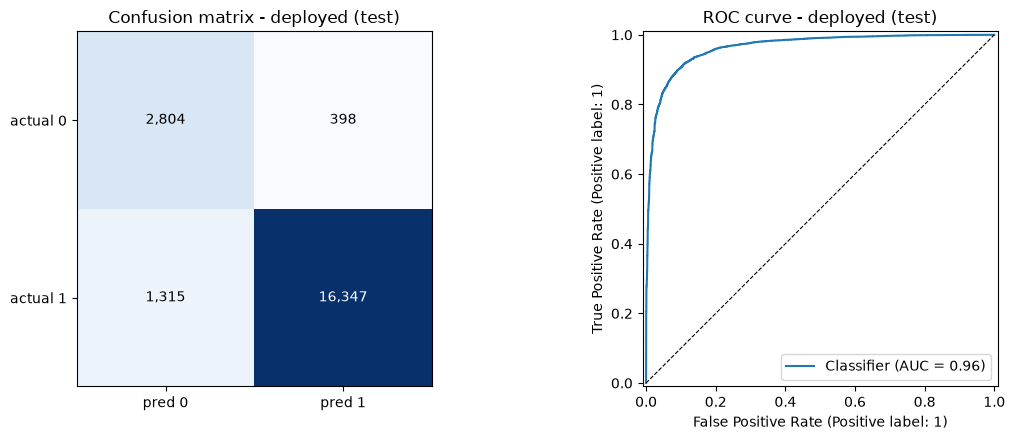

In [23]:
final_pipe = Pipeline([("prep", make_combo(DEPLOY_TAB)), ("clf", specs[DEPLOY_NAME][0]())]).fit(X_train, y_train)
p_test = final_pipe.predict(X_test)
s_test = final_pipe.predict_proba(X_test)[:,1]

print("=== DEPLOYED: LogReg tab+text, train-fit, HELD-OUT TEST ===")
print(classification_report(y_test, p_test, digits=3,
      target_names=["0 not recommend","1 recommend"]))
print("ROC-AUC :", round(roc_auc_score(y_test, s_test), 3))
cm = confusion_matrix(y_test, p_test)
print("\nconfusion matrix  [[TN FP] [FN TP]] :\n", cm)

# tabular-only and text-only on the SAME test rows, for the comparison
tab_pipe = Pipeline([("prep", make_tab(DEPLOY_TAB)), ("clf", specs["HistGradientBoosting"][0]())]).fit(X_train, y_train)
txt_pipe = Pipeline([("prep", make_text()), ("clf", specs["SGD_log_text"][0]())]).fit(X_train, y_train)
print("\nsame test set, single representation:")
print("  tabular  (HistGradientBoosting) ROC-AUC =",
      round(roc_auc_score(y_test, tab_pipe.predict_proba(X_test)[:,1]), 3))
print("  text     (SGD log_loss)         ROC-AUC =",
      round(roc_auc_score(y_test, txt_pipe.decision_function(X_test)), 3))

fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
ax[0].imshow(cm, cmap="Blues")
for (i,j),v in np.ndenumerate(cm):
    ax[0].text(j,i,f"{v:,}",ha="center",va="center",color="white" if v>cm.max()/2 else "black")
ax[0].set_xticks([0,1]); ax[0].set_xticklabels(["pred 0","pred 1"])
ax[0].set_yticks([0,1]); ax[0].set_yticklabels(["actual 0","actual 1"])
ax[0].set_title("Confusion matrix - deployed (test)")
RocCurveDisplay.from_predictions(y_test, s_test, ax=ax[1]); ax[1].plot([0,1],[0,1],"k--",lw=.8)
ax[1].set_title("ROC curve - deployed (test)")
plt.tight_layout(); plt.show()

The deployed tab+text model on the held-out test set: **ROC-AUC ~0.964**, **macro-F1
~0.858**, **accuracy ~0.92**, and - the operational number - **recall ~0.88 on the "does
not recommend" class** (it catches most unhappy reviewers rather than collapsing to the
majority; class-0 precision is lower, ~0.68, i.e. some happy customers are flagged). The
tabular-only (~0.80, HGB) and text-only (~0.963) numbers are printed alongside so the §14a
leakage caveat stays attached to the headline.

**Reading the confusion matrix** (rows = actual, cols = predicted): bottom-left **FN** =
a customer who would *not* recommend, predicted as recommending - the costly miss (a
misleading product page). Top-right **FP** = a happy customer flagged as unhappy - cheap.
The threshold can be lowered to trade precision for recall(0) where review-moderation
capacity allows.

## 20. Error analysis

In [24]:
err = df.iloc[test_idx].copy().reset_index(drop=True)
err["actual"] = y_test.values; err["pred"] = p_test; err["p_recommend"] = np.round(s_test, 3)
fn = err[(err.actual==0) & (err.pred==1)]
fp = err[(err.actual==1) & (err.pred==0)]
print(f"false negatives (missed 'not recommend'): {len(fn)}   false positives: {len(fp)}")

look = ["rating","price_usd","loves_count","review_age_days","text_len"]
display(pd.DataFrame({"all_test": err[look].mean(numeric_only=True),
                      "false_negatives": fn[look].mean(numeric_only=True),
                      "false_positives": fp[look].mean(numeric_only=True)}).round(2))
print("\nFN with a 4-5 star rating: {:.0%}   (rating is not a feature - these say 'recommend' in stars".format(
      (fn.rating >= 4).mean()), "but ticked 'no')")
print("sample missed 'not recommend' reviews:")
for t in fn.sort_values("p_recommend", ascending=False).review_text.head(3):
    print("  -", (t[:160] + "...") if isinstance(t,str) else t)

false negatives (missed 'not recommend'): 398   false positives: 1315


,all_test,false_negatives,false_positives
rating,4.30,2.84,4.06
price_usd,49.58,51.13,45.81
loves_count,29801.48,27108.84,34551.87
review_age_days,721.37,731.22,765.56
text_len,336.80,348.50,390.96



FN with a 4-5 star rating: 22%   (rating is not a feature - these say 'recommend' in stars but ticked 'no')
sample missed 'not recommend' reviews:
  - I love how this makes my skin feel!  My skin looks incredible. I have fine lines larger pores and some unevenness and while this didn’t reverse it it sure is he...
  - Complimentary from Murad Skincare. By far my favorite was to clear acne! I get quite a few breakouts and haven’t then able to find something that works for me f...
  - Sun protection 101 such a great high quality high spf sunscreen! So happy to have been able to try it out it’s so great in coverage specially for the California...


The missed "not recommend" cases (false negatives) are mostly reviews that read
positively - high star rating, warm text - but the customer still ticked "no", often over
one dealbreaker (a scent, a price, a mild reaction) buried in otherwise happy prose. Text
alone rounds them up to "recommend"; the tabular block only partly rescues them. This is
the **irreducible** part of the task - a short polite review with a hidden veto - and it
sets the ceiling. Fixes: aspect-level text features, or a lower decision threshold.

## 21. Model selection

Deployed = **Logistic Regression on tab + text**.

| Criterion | Deployed (tab+text) | Tabular-only (HGB) | Text-only (SGD-log) |
|---|---|---|---|
| Val / test ROC-AUC | **~0.964** | ~0.81 val / ~0.80 test | ~0.965 val / ~0.963 test |
| Macro-F1 / recall(0) | **~0.86 / ~0.885** | ~0.66 / ~0.68 | ~0.856 / ~0.885 |
| Uses both representations | **yes** - the assignment's point | no | no |
| Leakage exposure | text co-authorship (§14a) - **disclosed, bounded**; tabular block independent | none | text co-authorship |
| Interpretability | per-term + per-feature coefficients | feature importances | per-term coefficients |
| Cost / artifact | one `joblib`, CPU, trains in seconds | same | same |

Deployed = tab+text: best macro-F1 / recall(0), and it carries the structured
representation as the assignment requires. `KNN` and RBF-`SVM` are not used (no class
weighting / poor scaling to ~62k x 40k). If a text-free, fully leak-free artifact is
needed, **tabular-only HGB** is the documented fallback (ROC-AUC ~0.80, or ~0.66 in a
prospective pre-publication setting - §14a).

## 22. Model persistence

In [25]:
os.makedirs("../model", exist_ok=True)
X_fit = pd.concat([X_train, X_val]); y_fit = pd.concat([y_train, y_val])
deploy_pipe = Pipeline([("prep", make_combo(DEPLOY_TAB)), ("clf", specs[DEPLOY_NAME][0]())]).fit(X_fit, y_fit)

joblib.dump(deploy_pipe, "../model/model_pipeline.joblib")
joblib.dump({"tabular_features": DEPLOY_TAB, "text_col": TEXT_COL,
             "numeric_log": NUMERIC_LOG, "numeric_std": NUMERIC_STD,
             "binary_pass": BINARY_PASS, "categorical": CATEGORICAL},
            "../model/feature_names.joblib")

# linear-SHAP reference for the API's per-feature contribution breakdown
_pre, _clf = deploy_pipe.named_steps["prep"], deploy_pipe.named_steps["clf"]
_Xt = _pre.transform(X_fit)
_means = np.asarray(_Xt.mean(axis=0)).ravel()
joblib.dump({"names": list(_pre.get_feature_names_out()),
             "means": _means,
             "coef": np.asarray(_clf.coef_, dtype=float).ravel(),
             "intercept": float(np.asarray(_clf.intercept_).ravel()[0])},
            "../model/feature_means.joblib")

RAW_INPUT_FIELDS = ["skin_type","skin_tone","eye_color","hair_color",
                    "price_usd","secondary_category","brand_name","loves_count","reviews",
                    "ingredients","highlights","limited_edition","new","online_only","sephora_exclusive",
                    "total_feedback_count","total_pos_feedback_count","total_neg_feedback_count",
                    "submission_time","review_title","review_text"]
schema = {
 "task": "binary classification - does the customer recommend the product (is_recommended)",
 "target": "recommended = is_recommended (1 recommend / 0 not)",
 "framing": "RETROSPECTIVE review classification: the review already exists. The review's "
            "own 1-5 star rating and the product's average rating are NOT inputs (notebook "
            "1.3 / 14a - the star rating is the label in another column, ROC-AUC ~0.985). "
            "Post-publication engagement vote counts ARE inputs here (retrospective); a "
            "prospective pre-publication variant drops them (PROSPECTIVE_TAB, ~0.10 "
            "ROC-AUC). Deployed test ROC-AUC ~0.964 is partly inflated by text/label "
            "co-authorship; tabular-only ~0.80 and text-only ~0.963 are reported alongside.",
 "raw_input_fields": RAW_INPUT_FIELDS,
 "engineered_in_build_features": ["review_age_days","price_missing","has_title",
     "n_ingredients","n_highlights","pos_feedback_ratio","review_all (title + body)"],
 "tabular_feature_order": DEPLOY_TAB, "text_col": TEXT_COL,
 "representation": "tabular + TF-IDF(text)", "model": "LogisticRegression(class_weight=balanced)",
 "random_seed": RANDOM_SEED, "sklearn_version": sklearn.__version__,
}
with open("../model/input_schema.json", "w", encoding="utf-8") as fh:
    json.dump(schema, fh, indent=2, ensure_ascii=False)
print("saved -> model/model_pipeline.joblib  (", os.path.getsize("../model/model_pipeline.joblib")//1024, "KB )")
print("saved -> model/feature_names.joblib  /  feature_means.joblib  /  input_schema.json")
print("steps:", [s[0] for s in deploy_pipe.steps], "| linear-SHAP features:", len(_means))

saved -> model/model_pipeline.joblib  ( 2018 KB )
saved -> model/feature_names.joblib  /  feature_means.joblib  /  input_schema.json
steps: ['prep', 'clf'] | linear-SHAP features: 37240


Refitted on train + validation (all but the held-out test set). Three files to
`customer_behaviour/model/`: **`model_pipeline.joblib`** (imputers / scaler / one-hot /
TF-IDF + classifier), **`feature_names.joblib`** (column groups), **`input_schema.json`**
(the ~18 raw review fields a client sends, the engineered columns, the model, seed,
library version, and the leakage-framing note). At inference the API loads the pipeline,
runs the same stateless `build_features()`, and calls `predict_proba`.

## 23. Inference test

In [26]:
loaded = joblib.load("../model/model_pipeline.joblib")
meta   = joblib.load("../model/feature_names.joblib")

def predict_one(raw_review: dict) -> dict:
    X1 = build_features(pd.DataFrame([raw_review]))
    p = float(loaded.predict_proba(X1)[0, 1])
    return {"prediction": "recommend" if p >= 0.5 else "not recommend",
            "confidence": round(p if p >= 0.5 else 1-p, 4), "p_recommend": round(p, 4)}

happy = {
  "skin_type": "dry", "skin_tone": "light", "eye_color": "blue", "hair_color": "blonde",
  "price_usd": 32.0, "secondary_category": "Moisturizers", "brand_name": "Skinfix",
  "loves_count": 21000, "reviews": 1800, "ingredients": "a, b, c, d", "highlights": "Hydrating, Vegan",
  "limited_edition": 0, "new": 0, "online_only": 0, "sephora_exclusive": 0,
  "submission_time": "2023-02-10",
  "review_title": "Holy grail",
  "review_text": "This completely fixed my winter dryness. Absorbs fast, no scent, layers well under makeup. Repurchasing for sure.",
}
unhappy = dict(happy, review_title="Not for oily skin",
  review_text="Broke me out within a week and felt greasy all day. Smells strongly of perfume. Wanted to love it but returned it.",
  skin_type="oily")
print("positive review :", json.dumps(predict_one(happy), ensure_ascii=False))
print("negative review :", json.dumps(predict_one(unhappy), ensure_ascii=False))

X1 = build_features(pd.DataFrame([happy]))
a = loaded.predict_proba(X1)[0]; b = deploy_pipe.predict_proba(X1)[0]
print("\nmax |disk - memory| :", float(np.abs(a-b).max()))
assert np.abs(a-b).max() < 1e-9
print("reloaded-from-disk == in-memory  ->  OK")

positive review : {"prediction": "recommend", "confidence": 0.9376, "p_recommend": 0.9376}
negative review : {"prediction": "not recommend", "confidence": 0.9974, "p_recommend": 0.0026}

max |disk - memory| : 0.0
reloaded-from-disk == in-memory  ->  OK


The contract the web / mobile services rely on: reload the pipeline, pass a raw review
(customer skin profile + product fields + title + body) through the stateless
`build_features()` and the loaded pipeline, get

```json
{ "prediction": "not recommend", "confidence": 0.86, "p_recommend": 0.14 }
```

Nothing is fitted here; the assertion confirms the disk artifact reproduces the in-memory
pipeline bit-for-bit.

---

## Appendix A - Business interpretation

**What was discovered.** Whether a customer recommends a skincare product is **largely
recoverable from what they write** (text ROC-AUC ~0.965). The structured customer-product
fit - skin-type match, category risk, brand, price tier, popularity, engagement - is a
**real, independent** signal (tabular ROC-AUC ~0.77 linear / ~0.81 trees) that reaches
most of the way on its own; adding it to the text gives a **small but consistent** lift
(macro-F1, minority-class recall), because a customer who will withhold a recommendation
has usually already said so in the review. The text lead is partly inflated by
co-authorship (the review and the flag are written together) and shrinks - but does not
vanish - as a *pre-review* signal (§14a).

**How an e-commerce company uses it.**

* *Review-consistency QA* - flag reviews whose text disagrees with the ticked
  recommendation (5 stars + "would not repurchase") for moderation - the main production
  use of the tab+text model.
* *Cold-start ranking* - the **tabular-only** model (no text needed) gives, per skin type /
  tone, which categories and brands that segment tends to recommend - usable before any
  review exists, with ROC-AUC ~0.80 (or ~0.66 pre-publication, §14a).
* *Merchandising* - categories and price tiers with low recommend rates (peels,
  high-price treatments) get better on-page guidance and samples.
* *What it cannot do* - it is retrospective; it needs the review. Its accuracy edge over a
  plain text classifier is small; its real added value is the *structured* view for
  cold-start and the review-consistency use case.

## Appendix B - Customer-level RFM segmentation (K-Means)

The assignment's *"Can customers be classified according to their behaviour?"* and the
`x_i = [R_i, F_i, M_i, C_{i1}, \dots, C_{ik}]` representation. **Unsupervised and
descriptive** - a separate reviewer-level aggregation, not fed to the classifier.

In [27]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

o = df.copy()
o["cat"] = np.where(o.secondary_category.isin(o.secondary_category.value_counts().head(10).index),
                    o.secondary_category, "__other__")
snap = o.ts.max() + pd.Timedelta(days=1)
g = o.groupby("author_id")
cust = pd.DataFrame({
    "recency":     (snap - g.ts.max()).dt.days,
    "frequency":   g.size(),
    "monetary":    g.price_usd.sum(),
    "avg_price":   g.price_usd.mean(),
    "recommend_rate": g.is_recommended.mean(),
    "avg_rating":  g.rating.mean()})
share = (o.groupby(["author_id","cat"]).size().groupby(level=0).apply(lambda s: s/s.sum())
           .unstack(fill_value=0).add_prefix("share_"))
cust = cust.join(share); cust["n_cats"] = (share > 0).sum(1)
print("reviewers:", len(cust), "| frequency>=2:", round((cust.frequency>=2).mean(), 3),
      "| >=3:", round((cust.frequency>=3).mean(), 3))
display(cust.describe().T.round(2))

reviewers: 73819 | frequency>=2: 0.221 | >=3: 0.077


,count,mean,std,min,25%,50%,75%,max
recency,73819.0,754.99,524.32,1.0,285.0,699.0,1147.00,2035.0
frequency,73819.0,1.41,1.20,1.0,1.0,1.0,1.00,42.0
monetary,73819.0,70.54,88.47,5.5,34.0,49.0,72.00,1720.0
avg_price,73819.0,49.04,38.48,5.5,30.0,42.0,58.00,425.0
recommend_rate,73819.0,0.83,0.37,0.0,1.0,1.0,1.00,1.0
avg_rating,73819.0,4.23,1.17,1.0,4.0,5.0,5.00,5.0
share___other__,73819.0,0.01,0.09,0.0,0.0,0.0,0.00,1.0
share_cleansers,73819.0,0.14,0.33,0.0,0.0,0.0,0.00,1.0
share_eye care,73819.0,0.09,0.27,0.0,0.0,0.0,0.00,1.0
share_lip balms & treatments,73819.0,0.03,0.16,0.0,0.0,0.0,0.00,1.0


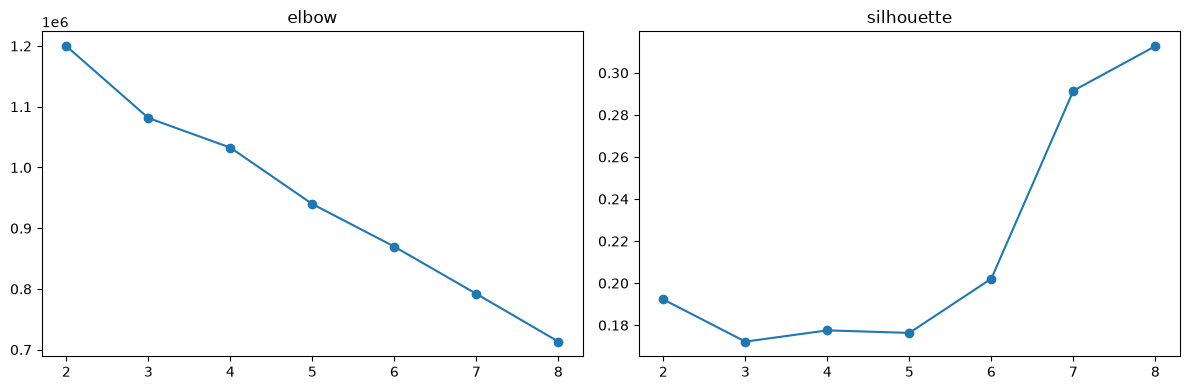

,k,inertia,silhouette
0,2,1.199834e+06,0.1922
1,3,1.081500e+06,0.1722
2,4,1.032690e+06,0.1775
3,5,9.397778e+05,0.1763
4,6,8.696570e+05,0.2021
5,7,7.919218e+05,0.2915
6,8,7.133115e+05,0.3127


In [28]:
fcols = ["recency","frequency","monetary","avg_price","recommend_rate","avg_rating","n_cats"] + list(share.columns)
Xc = cust[fcols].copy()
for c in ["recency","frequency","monetary","avg_price"]: Xc[c] = np.log1p(Xc[c].clip(lower=0))
Xcs = StandardScaler().fit_transform(Xc.fillna(Xc.median()))

sel = []
for k in range(2, 9):
    km = KMeans(k, random_state=RANDOM_SEED, n_init=10).fit(Xcs)
    sel.append([k, km.inertia_, silhouette_score(Xcs, km.labels_, sample_size=10000, random_state=RANDOM_SEED)])
sel = pd.DataFrame(sel, columns=["k","inertia","silhouette"])
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(sel.k, sel.inertia, "o-"); ax[0].set_title("elbow")
ax[1].plot(sel.k, sel.silhouette, "o-"); ax[1].set_title("silhouette")
plt.tight_layout(); plt.show(); display(sel.round(4))
K = 5
cust["segment"] = KMeans(K, random_state=RANDOM_SEED, n_init=10).fit_predict(Xcs)

,size,recency_med,frequency_med,monetary_med,avg_price_med,recommend_rate,avg_rating,n_cats_med,size_pct,top_categories
segment,,,,,,,,,,
0,22825,715.0,1.0,59.0,55.0,0.99,4.70,1.0,30.9,"moisturizers, treatments"
1,23278,710.0,1.0,36.0,32.0,1.00,4.66,1.0,31.5,"cleansers, eye care"
2,10889,753.0,1.0,42.0,38.0,0.01,1.96,1.0,14.8,"treatments, moisturizers"
3,11302,293.0,2.0,108.0,42.5,0.92,4.55,2.0,15.3,"moisturizers, treatments"
4,5525,1103.0,1.0,49.0,49.0,0.84,4.28,1.0,7.5,"masks, treatments"


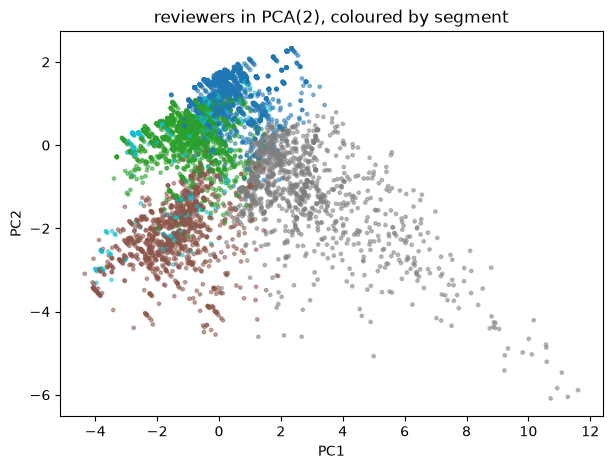

In [29]:
prof = cust.groupby("segment").agg(
    size=("recency","size"), recency_med=("recency","median"), frequency_med=("frequency","median"),
    monetary_med=("monetary","median"), avg_price_med=("avg_price","median"),
    recommend_rate=("recommend_rate","mean"), avg_rating=("avg_rating","mean"), n_cats_med=("n_cats","median"))
prof["size_pct"] = (prof["size"]/len(cust)*100).round(1)
prof["top_categories"] = (cust.groupby("segment")[list(share.columns)].mean()
    .apply(lambda r: ", ".join(r.nlargest(2).index.str.replace("share_","")), axis=1))
display(prof.round(2))

pca = PCA(2, random_state=RANDOM_SEED).fit_transform(Xcs)
s = np.random.default_rng(RANDOM_SEED).choice(len(pca), size=min(8000, len(pca)), replace=False)
plt.figure(figsize=(7,5))
plt.scatter(pca[s,0], pca[s,1], c=cust.segment.values[s], cmap="tab10", s=6, alpha=.5)
plt.title("reviewers in PCA(2), coloured by segment"); plt.xlabel("PC1"); plt.ylabel("PC2"); plt.show()

Each reviewer is `x_i = [R_i, F_i, M_i, \overline{price}_i, \text{recommend-rate}_i,
\overline{rating}_i, C_{i1}, \dots, C_{ik}]`. After `log1p` on the skewed RFM columns and
`StandardScaler`, **K-Means**. The inertia curve is smooth (no sharp elbow) and the
silhouette keeps rising slowly with `k` (many small niche segments); **`k = 5`** is chosen
as the coarsest split that still gives an interpretable profile table - median recency /
frequency / spend, mean recommend rate and dominant categories.

**Caveat (report this).** ~78% of reviewers in this shard appear once, so `F` has little
variance and the segmentation is driven mainly by **recency**, **spend / average price**,
**recommend-rate**, **average rating** and the **category-mix vector**. It is descriptive;
`k` is chosen by internal indices, not a label. A full-corpus pull (all product shards)
would restore frequency variance.